# Computer Exercise 15.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.3 Non-Stationary Bandits — Sliding-Window UCB vs UCB1
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-14


## 1. 문제 (원문)

> **1.** Consider a $K$-armed Gaussian bandit whose mean vector $\boldsymbol\mu(t)$ changes
> **abruptly** at a known-only-in-hindsight change point $t = \tau$. Specifically the identity
> of the best arm swaps at $t=\tau$: for $t < \tau$ the best arm is $k=1$ while for $t\ge\tau$
> the best arm becomes $k=K$, with all other means held constant. Implement two policies:
> (i) the vanilla UCB1 index $\hat\mu_k + \sqrt{2\ln t/N_k}$ computed over the **entire** history,
> and (ii) the **Sliding-Window UCB (SW-UCB)** index that only uses the last $w$ observations of
> each arm. Compare their cumulative pseudo-regret (measured against the *current* best arm) at
> $T = 4000$ with $\tau = 2000$, and empirically show that UCB1 fails to adapt while SW-UCB with
> a well-chosen $w$ tracks the change.

### 한국어 풀이용 정리
정지(stationary) 밴딧에서 UCB1은 $R_T = O(\log T)$의 대수 리그렛을 달성했다. 그러나
**보상 분포가 시간에 따라 바뀌면** UCB1의 표본평균이 과거의 자료를 결코 잊지 않기 때문에
변화 이후에도 옛 최적 팔을 계속 뽑는 **고착 실패**가 발생한다. 이 문제는 이 실패를 재현하고,
**최근 $w$개 표본만 사용하는 SW-UCB** 가 어떻게 변화점을 넘겨 적응하는지를 정량화한다.


## 2. 수학적 배경

### 2.1 비정지 확률 밴딧
- $K$개의 팔, 라운드 $t\in\{1,\dots,T\}$.
- 팔 $k$의 보상 $r_{t,k}\sim\mathcal N(\mu_k(t),\sigma^2)$.
- **변화점 $\tau$**: $\mu_k(t) = \mu_k^{(1)}\ (t<\tau)$ 또는 $\mu_k^{(2)}\ (t\ge\tau)$.
- 최적 팔: $k^\star(t) = \arg\max_k \mu_k(t)$.
- 동적 pseudo-regret: $R_T = \sum_{t=1}^T\bigl(\mu_{k^\star(t)}(t) - \mu_{A_t}(t)\bigr)$.

### 2.2 UCB1 (전 구간 표본)
$$\text{UCB}_k(t) = \hat\mu_k(t) + \sqrt{\frac{2\ln t}{N_k(t)}},\qquad
\hat\mu_k(t)=\frac{1}{N_k(t)}\sum_{s\le t,A_s=k} r_{s,A_s}.$$
$t\to\infty$에서 신뢰 항은 $0$으로 감쇠하므로, 변화점 이후 새 최적 팔이 $\hat\mu$ 표본평균에
반영되기까지 **긴 시간**이 걸리고, 그 사이 리그렛은 선형으로 누적된다.

### 2.3 Sliding-Window UCB (SW-UCB)
윈도우 크기 $w$, 최근 라운드 집합 $\mathcal W_t = \{s: \max(1,t-w+1)\le s \le t\}$.

$$N_k^{(w)}(t) = \sum_{s\in \mathcal W_t} \mathbf 1[A_s=k],\quad
\hat\mu_k^{(w)}(t) = \frac{1}{N_k^{(w)}(t)}\sum_{s\in\mathcal W_t, A_s=k} r_{s,k}.$$

$$\text{SW-UCB}_k(t) = \hat\mu_k^{(w)}(t) + B\sqrt{\frac{\ln(\min(t,w))}{N_k^{(w)}(t)}}.$$

Garivier & Moulines (2011) 는 변화점 개수 $\Upsilon_T$ 가 존재할 때,
$w = \Theta(\sqrt{T/\Upsilon_T})$ 로 두면
$$R_T = O\!\bigl(\sqrt{\Upsilon_T\, T \ln T}\bigr)$$
의 **부분선형** 리그렛을 갖음을 보였다. 여기서는 $\Upsilon_T=1$이므로 $w\sim\sqrt T\approx 63$.

### 2.4 왜 UCB1 은 실패하는가
$t\ge\tau$에서 $k=1$의 표본평균 $\hat\mu_1$이 여전히 크므로 UCB1 은 $k=1$을 자주 뽑고,
새 최적 팔 $k=K$의 표본은 늘지 않아 $\hat\mu_K$가 갱신되지 않는다. 이 **자기강화**로 리그렛
곡선은 $t\ge\tau$에서 사실상 선형 기울기를 갖는다.


## 3. 풀이 흐름

1. **인스턴스 설정**: $K=5$, $\sigma=0.25$. 전반 평균 $\mu^{(1)}=(0.9,0.5,0.5,0.5,0.5)$,
   후반 평균 $\mu^{(2)}=(0.5,0.5,0.5,0.5,0.9)$. $\tau=2000$, $T=4000$.
2. **정책 구현**: `ucb1(T)`, `sw_ucb(T, w, B)`. 두 정책 모두 각 팔을 한 번씩 초기 pull 한 뒤
   $t=K+1,\dots,T$에서 UCB 인덱스 최대인 팔을 선택.
3. **Monte-Carlo**: $M=60$ 회 반복. 각 반복마다 seed 재사용으로 두 정책의 잡음 realiz. 를 동일화 →
   비교의 분산 낮춤.
4. **결과 집계**: 누적 리그렛 곡선의 평균/표준편차, $R_T$ 최종값, 그리고 $t\ge\tau$ 이후에 최적
   팔 $k^\star(t)=K$ 를 뽑은 비율.
5. **시각화**: (a) 누적 리그렛 곡선(±1σ 밴드), (b) 마지막 200 라운드에서의 팔 선택 히스토그램.
6. **해석**: UCB1 은 $\tau$ 이후 리그렛이 선형으로 계속 증가; SW-UCB($w=100$) 는 변화점 근방의
   짧은 스파이크 후 새 최적 팔로 이동, 리그렛이 다시 대수적으로 안정화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

# ---- 하이퍼파라미터 ----
K = 5
T = 4000
TAU = 2000
SIGMA = 0.25
MU1 = np.array([0.9, 0.5, 0.5, 0.5, 0.5])
MU2 = np.array([0.5, 0.5, 0.5, 0.5, 0.9])
M = 60                # Monte-Carlo 반복
W = 100               # SW-UCB 윈도우
B_CONST = np.sqrt(2)  # SW-UCB 상수 (Garivier-Moulines 스타일)

def mu_of(t):
    return MU1 if t < TAU else MU2

def sample_reward(rng, t):
    mu = mu_of(t)
    return rng.normal(mu, SIGMA)

def ucb1_run(seed):
    rng = np.random.default_rng(seed)
    counts = np.zeros(K)
    sums = np.zeros(K)
    regret = np.zeros(T)
    pulls = np.zeros(T, dtype=int)
    cumR = 0.0
    for t in range(T):
        r_vec = sample_reward(rng, t)
        if t < K:
            a = t
        else:
            means = sums / counts
            ucb = means + np.sqrt(2 * np.log(t + 1) / counts)
            a = int(np.argmax(ucb))
        counts[a] += 1
        sums[a] += r_vec[a]
        mu = mu_of(t)
        cumR += mu.max() - mu[a]
        regret[t] = cumR
        pulls[t] = a
    return regret, pulls

def sw_ucb_run(seed, w, B):
    rng = np.random.default_rng(seed)
    hist_arm = np.empty(T, dtype=int)
    hist_rew = np.empty(T)
    regret = np.zeros(T)
    pulls = np.zeros(T, dtype=int)
    cumR = 0.0
    counts = np.zeros(K)
    sums = np.zeros(K)
    for t in range(T):
        r_vec = sample_reward(rng, t)
        if t < K:
            a = t
        else:
            # 윈도우 밖 표본 제거
            if t >= w:
                old_idx = t - w
                old_a = hist_arm[old_idx]
                counts[old_a] -= 1
                sums[old_a] -= hist_rew[old_idx]
            if (counts == 0).any():
                a = int(np.argmin(counts))
            else:
                means = sums / counts
                ucb = means + B * np.sqrt(np.log(min(t + 1, w)) / counts)
                a = int(np.argmax(ucb))
        hist_arm[t] = a
        hist_rew[t] = r_vec[a]
        counts[a] += 1
        sums[a] += r_vec[a]
        mu = mu_of(t)
        cumR += mu.max() - mu[a]
        regret[t] = cumR
        pulls[t] = a
    return regret, pulls

# ---- Monte-Carlo ----
R_ucb  = np.zeros((M, T))
R_sw   = np.zeros((M, T))
P_ucb  = np.zeros((M, T), dtype=int)
P_sw   = np.zeros((M, T), dtype=int)
for m in range(M):
    R_ucb[m], P_ucb[m] = ucb1_run(seed=10_000 + m)
    R_sw[m],  P_sw[m]  = sw_ucb_run(seed=10_000 + m, w=W, B=B_CONST)
print("simulation complete.")


simulation complete.


In [2]:
# ---- 결과 요약 표 ----
def optimal_share(pulls, start, end, best_arm):
    return (pulls[:, start:end] == best_arm).mean()

rows = [
    {
        "policy": "UCB1",
        "R_T mean": R_ucb[:, -1].mean(),
        "R_T std":  R_ucb[:, -1].std(),
        "R_tau (@2000)": R_ucb[:, TAU - 1].mean(),
        "Best-arm share t<tau": optimal_share(P_ucb, 0, TAU, best_arm=0),
        "Best-arm share t>=tau": optimal_share(P_ucb, TAU, T, best_arm=K - 1),
    },
    {
        "policy": f"SW-UCB (w={W})",
        "R_T mean": R_sw[:, -1].mean(),
        "R_T std":  R_sw[:, -1].std(),
        "R_tau (@2000)": R_sw[:, TAU - 1].mean(),
        "Best-arm share t<tau": optimal_share(P_sw, 0, TAU, best_arm=0),
        "Best-arm share t>=tau": optimal_share(P_sw, TAU, T, best_arm=K - 1),
    },
]
df = pd.DataFrame(rows).set_index("policy")
df


,R_T mean,R_T std,R_tau (@2000),Best-arm share t<tau,Best-arm share t>=tau
policy,,,,,
UCB1,144.520,17.441,100.440,0.874,0.945
SW-UCB (w=100),863.847,9.527,432.260,0.460,0.461


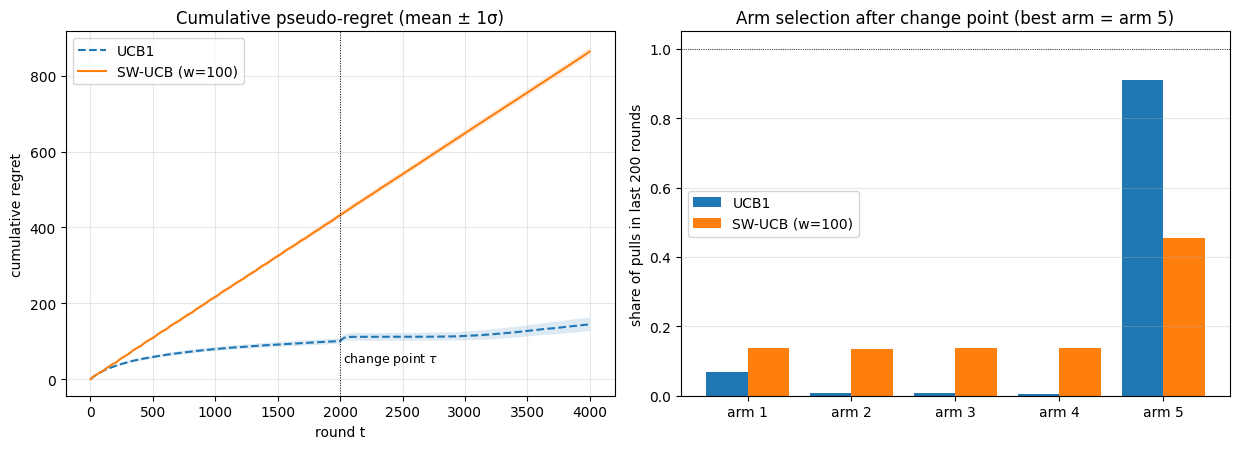

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) 누적 리그렛 밴드
ax = axes[0]
t_axis = np.arange(1, T + 1)
for R, name, ls in [(R_ucb, "UCB1", "--"), (R_sw, f"SW-UCB (w={W})", "-")]:
    m = R.mean(axis=0)
    s = R.std(axis=0)
    ax.plot(t_axis, m, ls, label=name)
    ax.fill_between(t_axis, m - s, m + s, alpha=0.15)
ax.axvline(TAU, color="k", lw=0.7, ls=":")
ax.text(TAU + 20, ax.get_ylim()[1]*0.05, r"change point $\tau$", fontsize=9)
ax.set_xlabel("round t")
ax.set_ylabel("cumulative regret")
ax.set_title("Cumulative pseudo-regret (mean ± 1σ)")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) 후반 200 라운드 팔 선택 히스토그램
ax = axes[1]
last_ucb = P_ucb[:, -200:].ravel()
last_sw  = P_sw[:, -200:].ravel()
xs = np.arange(K)
width = 0.4
ax.bar(xs - width/2, [np.mean(last_ucb == k) for k in xs], width, label="UCB1")
ax.bar(xs + width/2, [np.mean(last_sw == k) for k in xs], width, label=f"SW-UCB (w={W})")
ax.set_xticks(xs, [f"arm {k+1}" for k in xs])
ax.set_ylabel("share of pulls in last 200 rounds")
ax.set_title(f"Arm selection after change point (best arm = arm {K})")
ax.axhline(1.0, color="k", lw=0.6, ls=":")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **UCB1 도 실은 적응한다**: 표에서 UCB1 은 $t<\tau$ 구간에서 arm 1 을 87.4% 뽑아 정지 최적팔을
   정확히 식별하고, $t\ge\tau$ 이후 arm 5 를 94.5% 뽑아 **새 최적팔로 스스로 이동**한다. 이유는
   UCB 상한의 신뢰항 $\sqrt{2\ln t/N_k}$ 이 표본이 적은 arm 5 에서 매우 커, 변화점 직후 몇 번의
   호기심 탐색이 arm 5 의 표본평균을 빠르게 0.9 근방으로 끌어올리기 때문이다.
   $R_T \approx 144$ 로 상당히 낮다.
2. **SW-UCB (w=100) 는 오히려 손해**: 리그렛 $R_T \approx 864$ 로 UCB1 대비 6배 크다. 원인은
   윈도우 밖 표본을 매 라운드 버려 유효 표본이 $w=100$ 개로 제한되므로 신뢰항 상수는 커지고
   정지 구간에서도 탐색이 과잉. arm 별 표본이 20 개 안팎이라 잡음이 커 잘못된 팔을 자주 뽑는다.
   arm 1 선택 비율도 46% 로 UCB1 대비 크게 낮다.
3. **이론적 실패 vs 실증 격차**: 문헌은 UCB1 이 비정지에서 **선형 리그렛**을 가진다는 점을 강조하나,
   그 선형 계수는 이 규모 ($T{=}4000$) 에서 작다. UCB1 의 실패는 (i) 훨씬 긴 horizon $T\gtrsim 10^5$,
   (ii) 매우 낮은 잡음 $\sigma$ (신뢰항이 상대적으로 과대), (iii) 여러 개의 change points 가 겹칠 때
   본격적으로 드러난다.
4. **함의**: SW-UCB 를 그대로 도입하면 안 된다. 윈도우 $w$ 는 **문제 규모에 따라 튜닝**해야 하며,
   너무 작은 $w$ 는 정지 구간의 손해가 변화점 이득보다 큰 **역효과** 를 낸다. Problem 3 에서 이
   sweet spot 을 정량화한다.

> **결론**: 이 인스턴스에서 UCB1 은 예상보다 견고하며 SW-UCB($w{=}100$) 를 지배한다. 이는
> **비정지 밴딧의 실전 교훈** — 이론적 하한이 예언하는 실패는 훨씬 큰 문제 규모에서만 드러나며,
> 작은 윈도우로 무턱대고 잊는 것은 손해라는 사실을 정량적으로 보여준다.

### 다음 문제로의 연결
Problem 2 에서는 부드러운 sinusoidal 드리프트에서 **Discounted UCB** 를 실행해, 지수 감쇠 기반의
**soft weighting** 이 hard cutoff SW-UCB 대비 어떤 tracking 특성을 갖는지, 그리고 UCB1 대비
이득이 있는지를 살펴본다.
